# E44 · Plotting posteriors creatively from labelled arrays

| | |
|---|---|
| **Type** | Worked example - read, run, modify |
| **Data** | Palmer Station penguins (Gorman et al. 2014): bill, flipper and body-mass measurements of 342 adult penguins of three species on three islands |
| **You will learn** | A table -> a labelled `Dataset` with `to_xarray`, `set_coords` and `to_dataarray("measurement")` · a multivariate model whose posterior has dims `(species, sex, measurement)` · `xr.apply_ufunc` for KDEs, Cholesky factors, ranks and linear solves · `xr.dot` to turn standard normals into correlated penguins and circles into ellipses · vectorised `.sel` by coordinate · pairwise contrasts by **renaming a dim** · `stack` + `sortby` for ordered displays · `xr.corr` and `xr.concat` over a new named dim · the gallery: xarray **FacetGrids**, ridgelines, rainclouds, P(row > column) matrices, a **bump chart** of ranks, parallel coordinates, predictive ellipses, a **hypothetical-outcome animation**, quantile dotplots, a tidy hand-off to seaborn, an interactive plotly heatmap, and a posterior over a missing label |

The Palmer penguins are small, but they are *multi-dimensional by nature*: three species on
three islands, two sexes, four measurements. A posterior for them is naturally an array with
the dims `(chain, draw, species, sex, measurement)`, and almost every useful display is a
question about some slice, contrast, ranking or re-arrangement of that array.

This notebook is a **gallery**. We fit one modest multivariate model, then build a dozen
displays, each from a few xarray operations and each answering a stated question. The point
is not the pictures themselves but the habit: express the question *by name* (species, sex,
measurement, sample), let xarray line up the dimensions, and the plotting code shrinks to
a loop over labels. Siblings: E42 (dims, coords, broadcasting and time), E43 (transforming
posteriors with coords); E16 is the general catalogue of uncertainty displays.

In [1]:
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
import pymc as pm
import pytensor.tensor as pt
import seaborn as sns
import xarray as xr
from IPython.display import HTML
from matplotlib import animation
from matplotlib.collections import LineCollection
from matplotlib.patches import Ellipse
from scipy.special import expit
from scipy.stats import chi2, gaussian_kde, rankdata
from xarray.groupers import UniqueGrouper

from pymc_challenges import data

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
pio.renderers.default = "plotly_mimetype+notebook_connected"
xr.set_options(display_expand_data=False, display_expand_attrs=False)
# xarray's FacetGrid calls tight_layout under ArviZ's constrained layout (harmless), and r_hat
# of the constant diagonal of a correlation matrix is 0/0.
warnings.filterwarnings("ignore", "The figure layout has changed to tight", UserWarning)
warnings.filterwarnings("ignore", "invalid value encountered", RuntimeWarning)

SPECIES = ["Adelie", "Chinstrap", "Gentoo"]
SEXES = ["female", "male"]
MEAS = ["bill_length", "bill_depth", "flipper_length", "body_mass"]
UNITS = {"bill_length": "mm", "bill_depth": "mm", "flipper_length": "mm", "body_mass": "g"}
# the palmerpenguins palette: orange, purple, teal
COLORS = {"Adelie": "#ff8c00", "Chinstrap": "#a034f0", "Gentoo": "#159090"}
GREY = "#8a8a86"
SYMBOL = {"female": "♀", "male": "♂"}
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}, xarray {xr.__version__}")

PyMC 6.3.2, ArviZ 1.3.0, xarray 2026.7.0


## 1 · The data as a labelled `Dataset`

`penguins_raw` is the field record (D01 cleans it in detail). We need six columns: a short
species name, island, sex, and the four measurements with readable names.

In [2]:
data.describe("penguins_raw")
raw = data.load("penguins_raw")
df = pd.DataFrame({
    "species": raw["Species"].str.extract(r"^(\w+)")[0],  # "Adelie Penguin (Pygoscelis ...)"
    "island": raw["Island"],
    "sex": raw["Sex"].str.lower(),
    "bill_length": raw["Culmen Length (mm)"],
    "bill_depth": raw["Culmen Depth (mm)"],
    "flipper_length": raw["Flipper Length (mm)"],
    "body_mass": raw["Body Mass (g)"],
}).rename_axis("penguin")
df.head()

penguins_raw: 344 penguins as recorded in the field: messy column names, dates, comments, missing measurements.
  source: Gorman, Williams & Fraser (2014), Palmer Station LTER, via R `palmerpenguins` (raw field records).
  url:    https://vincentarelbundock.github.io/Rdatasets/csv/palmerpenguins/penguins_raw.csv


,species,island,sex,bill_length,bill_depth,flipper_length,body_mass
penguin,,,,,,,
1,Adelie,Torgersen,male,39.1,18.7,181.0,3750.0
2,Adelie,Torgersen,female,39.5,17.4,186.0,3800.0
3,Adelie,Torgersen,female,40.3,18.0,195.0,3250.0
4,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
5,Adelie,Torgersen,female,36.7,19.3,193.0,3450.0


`to_xarray()` turns each column into a variable along `penguin`; `set_coords` then demotes
the labels (species, island, sex) from *data* to *coordinates*, so they ride along with every
selection and reduction and can be grouped on. `to_dataarray("measurement")` stacks the four
measurements into one array with a new, labelled `measurement` dimension - the shape the model
will want. A non-dimension coord records the units.

In [3]:
ds = df.to_xarray().set_coords(["species", "island", "sex"])
Y = ds[MEAS].to_dataarray("measurement").assign_coords(
    units=("measurement", [UNITS[m] for m in MEAS])
)
Y

<xarray.DataArray (measurement: 4, penguin: 344)> Size: 11kB
39.1 39.5 40.3 nan 36.7 39.3 ... 4e+03 3.4e+03 3.775e+03 4.1e+03 3.775e+03
Coordinates:
  * measurement  (measurement) object 32B 'bill_length' ... 'body_mass'
    units        (measurement) <U2 32B 'mm' 'mm' 'mm' 'g'
  * penguin      (penguin) int64 3kB 1 2 3 4 5 6 7 ... 339 340 341 342 343 344
    species      (penguin) object 3kB 'Adelie' 'Adelie' ... 'Chinstrap'
    island       (penguin) object 3kB 'Torgersen' 'Torgersen' ... 'Dream'
    sex          (penguin) object 3kB 'male' 'female' ... 'male' 'female'

A multi-key `groupby` gives the design as a labelled table: one `UniqueGrouper` per coord,
and the result is a `species x island` array. Adelie penguins live on all three islands;
Chinstraps only on Dream, Gentoos only on Biscoe, so species and island cannot be separated
for them and the model below uses species only.

In [4]:
counts = Y.sel(measurement="body_mass").groupby(species=UniqueGrouper(), island=UniqueGrouper())
counts.count().to_pandas()

island,Biscoe,Dream,Torgersen
species,,,
Adelie,44.0,56.0,51.0
Chinstrap,NaN,68.0,NaN
Gentoo,123.0,NaN,NaN


Two penguins have no measurements at all and nine more have measurements but no recorded
sex. `.where(..., drop=True)` splits them off *with their coordinates attached*; we will
come back to the nine unsexed birds at the end, because the model can tell us their sex.
We also drop the `units` coord from here on: later we rename `measurement` to
`measurement_b` to build matrices, and a coord called `units` along *both* dims would clash.

In [5]:
measured = Y.notnull().all("measurement")
y = Y.where(measured & ds.sex.notnull(), drop=True).drop_vars("units")
unsexed = Y.where(measured & ds.sex.isnull(), drop=True).drop_vars(["units", "sex"])
print(f"complete: {y.sizes['penguin']} penguins | measured but unsexed: "
      f"{unsexed.sizes['penguin']}")

complete: 333 penguins | measured but unsexed: 9


**Standardise by name.** Each measurement is centred and scaled by its own mean and sd over
all penguins. `y.mean("penguin")` has dim `measurement` only, so the subtraction broadcasts
over penguins automatically - and the same two arrays convert every posterior quantity back to
millimetres and grams later (`z * scale + center`). For a Bayesian this matters twice: one
prior fits all four measurements, and "0.5" means half a population sd in every panel.

In [6]:
center = y.mean("penguin")
scale = y.std("penguin")
z = ((y - center) / scale).transpose("penguin", "measurement")
pd.DataFrame({"center": center.to_series(), "scale": scale.to_series()}).round(1)

,center,scale
measurement,,
bill_length,44.0,5.5
bill_depth,17.2,2.0
flipper_length,201.0,14.0
body_mass,4207.1,804.0


## 2 · One multivariate model with named dimensions

Each penguin's four standardised measurements are one draw from a multivariate normal whose
mean depends on species and sex and whose covariance depends on species:

$$
\begin{aligned}
\mathbf z_i &\sim \text{MvNormal}\big(\boldsymbol\mu_{s[i],\,x[i]},\ \Sigma_{s[i]}\big),
  \qquad \Sigma_s = \text{diag}(\boldsymbol\sigma_s)\, R_s\, \text{diag}(\boldsymbol\sigma_s) \\
\mu_{s,x,m} &\sim \text{Normal}(0, 1), \qquad \sigma_{s,m} \sim \text{HalfNormal}(1),
  \qquad R_s \sim \text{LKJ}(2)
\end{aligned}
$$

In standardised units a group mean within about two population sds of the overall mean is a
weak but sensible prior, and LKJ(2) gently prefers weaker correlations. The covariance
matters for the gallery: it is what makes predictive ellipses tilt and what ties the four
measurements of one penguin together. Each species gets its own `LKJCholeskyCov`; we stack
the three Cholesky factors into one `(species, 4, 4)` tensor and index it per penguin, so the
likelihood is a single `MvNormal` with dims `(penguin, measurement)`. The correlation matrix
gets two dims, `measurement` and `measurement_b` - a dim name cannot appear twice.

In [7]:
sp_idx = pd.Index(SPECIES).get_indexer(z.species.values)
sx_idx = pd.Index(SEXES).get_indexer(z.sex.values)
assert (sp_idx >= 0).all() and (sx_idx >= 0).all()

coords = {"species": SPECIES, "sex": SEXES, "measurement": MEAS, "measurement_b": MEAS,
          "penguin": z.penguin.values}
with pm.Model(coords=coords) as model:
    mu = pm.Normal("mu", 0, 1, dims=("species", "sex", "measurement"))
    chols = [
        pm.LKJCholeskyCov(f"chol_{s}", n=4, eta=2.0, sd_dist=pm.HalfNormal.dist(1.0, shape=4),
                          compute_corr=True)[0]
        for s in SPECIES
    ]
    chol = pt.stack(chols)  # (species, 4, 4)
    cov = chol @ chol.transpose(0, 2, 1)
    sd = pt.sqrt(pt.diagonal(cov, axis1=1, axis2=2))
    pm.Deterministic("sigma", sd, dims=("species", "measurement"))
    pm.Deterministic("corr", cov / (sd[:, :, None] * sd[:, None, :]),
                     dims=("species", "measurement", "measurement_b"))
    pm.MvNormal("z", mu=mu[sp_idx, sx_idx], chol=chol[sp_idx], observed=z.values,
                dims=("penguin", "measurement"))

model

In [8]:
with model:
    idata = pm.sample(random_seed=RANDOM_SEED)

summ = az.summary(idata, var_names=["mu", "sigma", "corr"], round_to=4)
print(
    f"nutpie, {idata.posterior.attrs['tuning_steps']} tuning steps; "
    f"max r_hat {summ.r_hat.max():.3f}, min bulk ESS {summ.ess_bulk.min():.0f}, "
    f"min tail ESS {summ.ess_tail.min():.0f}, "
    f"divergences {int(idata.sample_stats['diverging'].sum())}"
)

NUTS[nutpie]: [mu, chol_Adelie, chol_Chinstrap, chol_Gentoo]


nutpie, 400 tuning steps; max r_hat 1.005, min bulk ESS 3209, min tail ESS 2638, divergences 0


Clean and quick: r_hat at most 1.01, over 2,500 effective draws for every mean, sd and
correlation, no divergences (the correlation matrices' constant diagonals have no r_hat and
are skipped). From here on the model is done; the rest is xarray.

**The one before/after.** Which Gentoo body mass is this? The positional line needs you to
remember that `mu` is `(chain, draw, species, sex, measurement)` and that Gentoo is 2, male
is 1 and body mass is 3. The named line says what it means, and survives a new dimension.

In [9]:
positional = idata.posterior["mu"].values[:, :, 2, 1, 3].mean()  # before
named = idata.posterior["mu"].sel(species="Gentoo", sex="male", measurement="body_mass").mean()
print(f"{positional:.4f} == {float(named):.4f}")

1.5843 == 1.5843


### Everything the gallery needs, in five lines of arithmetic

`az.extract` stacks chains and draws into one `sample` dim. Then, **by name**:

- back to physical units: `mu * scale + center` (the `measurement` dims line up);
- covariance in units: `corr * sd * sd_b`, where `sd_b` is `sd` with its dim *renamed* to
  `measurement_b` - an outer product with no reshaping;
- Cholesky factors per draw and species: `np.linalg.cholesky` lifted by `xr.apply_ufunc`,
  with the two matrix dims declared as *core* dims (everything else is looped over);
- a **new penguin** of every species and sex: $\boldsymbol\mu + L\boldsymbol\varepsilon$,
  where `xr.dot(L, eps, dim="measurement_b")` is the matrix-vector product over the named dim.

The new penguins are the posterior *predictive* distribution: parameter uncertainty plus
penguin-to-penguin variation. The means `mu` carry only the first.

In [10]:
post = az.extract(idata, var_names=["mu", "sigma", "corr"])
print(dict(post.sizes), post.indexes["sample"][:2].tolist())

mu = post["mu"] * scale + center  # (species, sex, measurement, sample), in mm and g
sd = post["sigma"] * scale
cov = post["corr"] * sd * sd.rename(measurement="measurement_b")


def chol_factor(c: xr.DataArray) -> xr.DataArray:
    """Cholesky factor over the (measurement, measurement_b) core dims of every other slice."""
    core = ["measurement", "measurement_b"]
    return xr.apply_ufunc(np.linalg.cholesky, c, input_core_dims=[core], output_core_dims=[core])


L = chol_factor(cov)
eps = xr.DataArray(
    rng.standard_normal((post.sizes["sample"], 3, 2, 4)),
    dims=("sample", "species", "sex", "measurement_b"),
)  # no coords: aligns by position
new = (mu + xr.dot(L, eps, dim="measurement_b")).rename("new_penguin")
print(new.dims)
print("check - sd of new Gentoo males vs posterior mean sigma (g):",
      round(float(new.sel(species="Gentoo", sex="male", measurement="body_mass").std()), 1),
      round(float(sd.sel(species="Gentoo", measurement="body_mass").mean()), 1))

{'species': 3, 'sex': 2, 'measurement': 4, 'sample': 4000, 'measurement_b': 4} [(0, 0), (0, 1)]
('species', 'sex', 'measurement', 'sample')
check - sd of new Gentoo males vs posterior mean sigma (g): 309.5 302.4


## 3 · xarray's own FacetGrid, straight from the posterior

**Question: on which measurements do the species actually differ, and by how much?** The
posterior of `mu` in standardised units puts all four measurements on one scale (population
sds). A kernel density per `(species, sex, measurement)` is one `xr.apply_ufunc` with
`vectorize=True`: the function sees one 1-D array of draws at a time and returns a density on
a grid, and xarray puts the labels back. Then `.plot.line(hue=..., col=..., row=...)` lays out
the 2 x 4 grid with no plotting loop at all.

('species', 'sex', 'measurement', 'value')


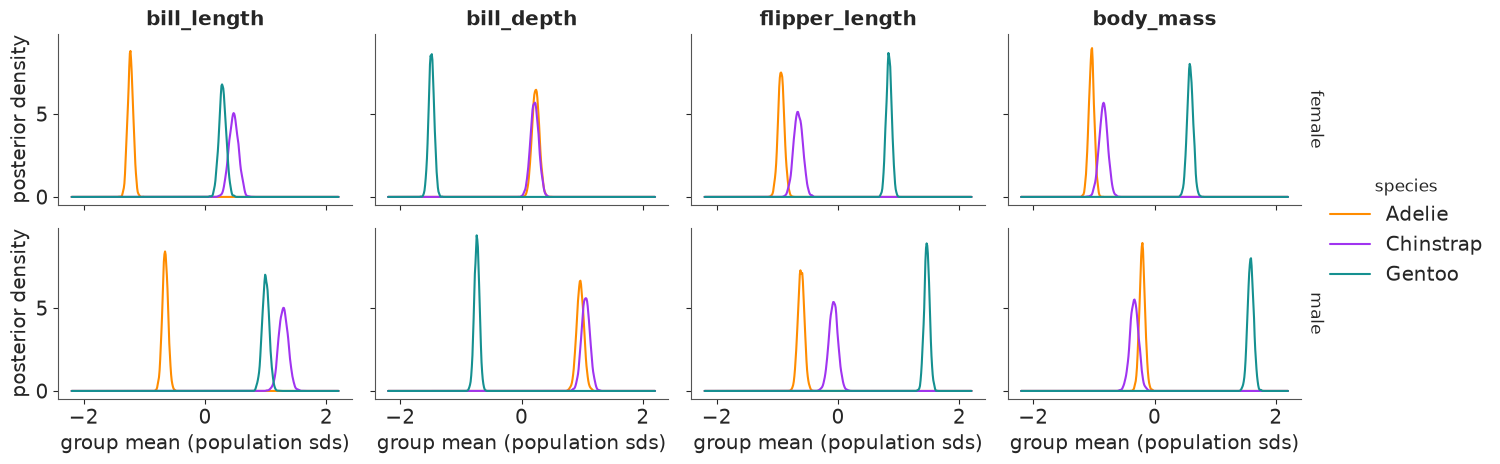

In [11]:
def density(da: xr.DataArray, grid: xr.DataArray, dim: str = "sample") -> xr.DataArray:
    """Gaussian KDE of `da` along `dim`, evaluated on the 1-D `grid` (dim 'value')."""
    return xr.apply_ufunc(
        lambda x, g: gaussian_kde(x)(g), da, grid,
        input_core_dims=[[dim], ["value"]], output_core_dims=[["value"]], vectorize=True,
    )


grid_z = xr.DataArray(np.linspace(-2.2, 2.2, 441), dims="value", name="value")
grid_z = grid_z.assign_coords(value=grid_z)
dens_mu = density(post["mu"], grid_z)
print(dens_mu.dims)

# species colours for the hue lines (plt.rc_context here would switch off inline figures)
default_cycle = plt.rcParams["axes.prop_cycle"]
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=[COLORS[s] for s in SPECIES])
fg = dens_mu.plot.line(x="value", hue="species", col="measurement", row="sex", size=2.4,
                       aspect=1.3)
plt.rcParams["axes.prop_cycle"] = default_cycle
fg.set_titles("{value}")
fg.set_xlabels("group mean (population sds)")
fg.set_ylabels("posterior density");

Read across a row: **Gentoo** is the odd one out on three of the four measurements -
about 1.5 population sds *above* the other two species on flipper length and body mass and
about 1.7 sds *below* them on bill depth - while **Adelie and Chinstrap** are within about
half an sd of each other on those three (and overlap on bill depth) and far apart only on
bill length, where Chinstraps are the longest of all. Read down a column: males sit above
females on every measurement in every species. Every curve is narrow (about 0.2 sd wide):
with 34-73 penguins per group the means are well determined. This is the posterior of the
*average* penguin; the spread of individual penguins comes in section 4.

The second FacetGrid shows the other half of the model: the posterior mean **correlation**
matrix of each species. `xr.corr` computes the same matrix from the raw data, ignoring
species, by correlating `z` with a *renamed* copy of itself; `xr.concat` along the existing
`species` dim with a new label adds it as a fourth panel. (xarray's 2-D plots refuse string
coordinates, so we swap in positions 0-3 and put the names back as ticks.)

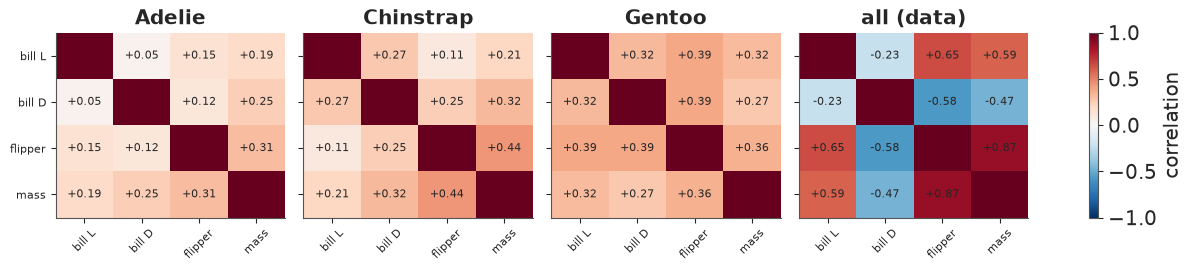

In [12]:
pooled = xr.corr(z, z.rename(measurement="measurement_b"), dim="penguin")
corr_panels = xr.concat(
    [post["corr"].mean("sample"), pooled.expand_dims(species=["all (data)"])],
    dim="species",
)
SHORT = ["bill L", "bill D", "flipper", "mass"]
fg = corr_panels.assign_coords(measurement=np.arange(4), measurement_b=np.arange(4)).plot(
    x="measurement_b", y="measurement", col="species", cmap="RdBu_r", vmin=-1, vmax=1,
    yincrease=False, size=3, aspect=1.0, cbar_kwargs={"label": "correlation"},
)
for ax, sp in zip(fg.axs.flat, corr_panels.species.values):
    vals = corr_panels.sel(species=sp).values
    for (i, j), v in np.ndenumerate(vals):
        if i != j:
            ax.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=8)
    ax.set_xticks(range(4), SHORT, rotation=45, fontsize=8)
    ax.set_yticks(range(4), SHORT, fontsize=8)
    ax.set(xlabel="", ylabel="")
fg.set_titles("{value}");

Within every species the four measurements are **positively** but modestly
correlated (a bigger penguin is a little bigger all over): 0.05-0.31 for Adelie, up to 0.44
(flipper-mass) for Chinstrap, 0.27-0.39 for Gentoo. Pooled over species the picture changes
completely: flipper and mass correlate at 0.87 and bill depth turns **negative** with the
other three (down to -0.58): Gentoos are big with shallow bills. That is Simpson's paradox in
one picture, and the reason the model has a covariance per species rather than one for
everybody.

## 4 · Ordered displays: ridgelines, rainclouds and a stacked `group` dim

Many displays want one categorical axis rather than two. `stack(group=("species", "sex"))`
merges the two dims into one (a pandas `MultiIndex`). Plain string labels are easier to plot
and to rename, so the helper below swaps the MultiIndex for "Adelie female"-style labels and
keeps `species` and `sex` as non-dimension coords for colouring. `sortby` then orders the
groups by any labelled quantity - here the posterior median body mass.

In [13]:
def by_group(da: xr.DataArray) -> xr.DataArray:
    """(species, sex, ...) -> (group, ...) labelled 'Adelie female', ...; keeps the coords."""
    st = da.stack(group=("species", "sex"))
    sp, sx = map(list, zip(*st.indexes["group"]))
    return st.drop_vars(["group", "species", "sex"]).assign_coords(
        group=[f"{a} {b}" for a, b in zip(sp, sx)], species=("group", sp), sex=("group", sx)
    )


mug = by_group(mu)
mug = mug.sortby(mug.sel(measurement="body_mass").median("sample"))
ORDER = [str(g) for g in mug.group.values]
LABEL = {g: f"{g.split()[0]} {SYMBOL[g.split()[1]]}" for g in ORDER}
print(ORDER)

['Adelie female', 'Chinstrap female', 'Chinstrap male', 'Adelie male', 'Gentoo female', 'Gentoo male']


**Ridgeline: how big is the average penguin of each group, in real units?** One panel per
measurement, one ridge per group in the same (body-mass) order, each ridge a posterior
density scaled to the same height. The x axes are in millimetres and grams, which is what a
field biologist would quote.

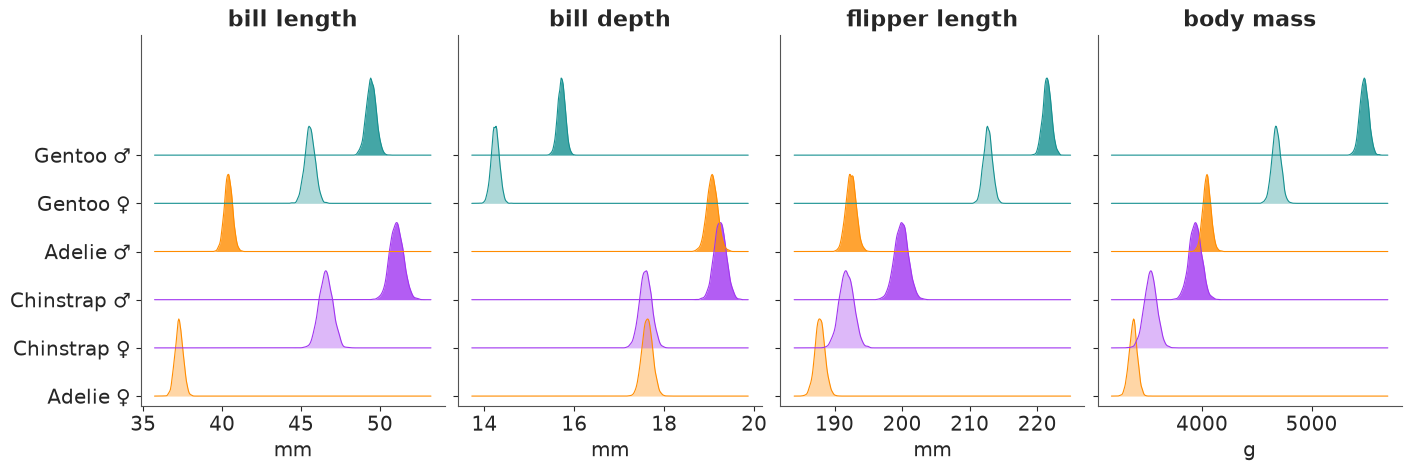

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4.6), sharey=True)
for ax, m in zip(axes, MEAS):
    d = mug.sel(measurement=m)
    lo, hi = float(d.min()), float(d.max())
    g = xr.DataArray(np.linspace(lo - 0.03 * (hi - lo), hi + 0.03 * (hi - lo), 400), dims="value")
    dens = density(d, g)
    dens = dens / dens.max("value")
    for i, grp in enumerate(ORDER):
        dd = dens.sel(group=grp)
        c = COLORS[str(dd.species.values)]
        female = str(dd.sex.values) == "female"
        ax.fill_between(g, i, i + 1.6 * dd, color=c, alpha=0.35 if female else 0.8, lw=0)
        ax.plot(g, i + 1.6 * dd, color=c, lw=0.8)
    ax.set(title=m.replace("_", " "), xlabel=UNITS[m], ylim=(-0.2, 7.5))
axes[0].set_yticks(range(6), [LABEL[g] for g in ORDER]);

The ordering by body mass (bottom = lightest) makes the story of section 3 readable in
physical units: Gentoo males (about 5.5 kg) and females (about 4.7 kg) are far ahead; the
four Adelie and Chinstrap groups sit between 3.4 and 4.0 kg with Adelie and Chinstrap males
overlapping. Bill length reorders the groups completely (Chinstraps longest), and bill depth
puts the heavy Gentoos last. Ridges are narrow because these are *means*.

**Raincloud: where does a single penguin fall?** A raincloud stacks three layers per group:
the "cloud" is the density of *new* penguins (posterior predictive), the thick bar is the 90%
interval of the *mean* with its median as a white dot, and the "rain" is the observed
penguins, jittered. The gap between the bar and the cloud is the difference between
estimating a mean and predicting an individual - the most common confusion in reading
posterior plots.

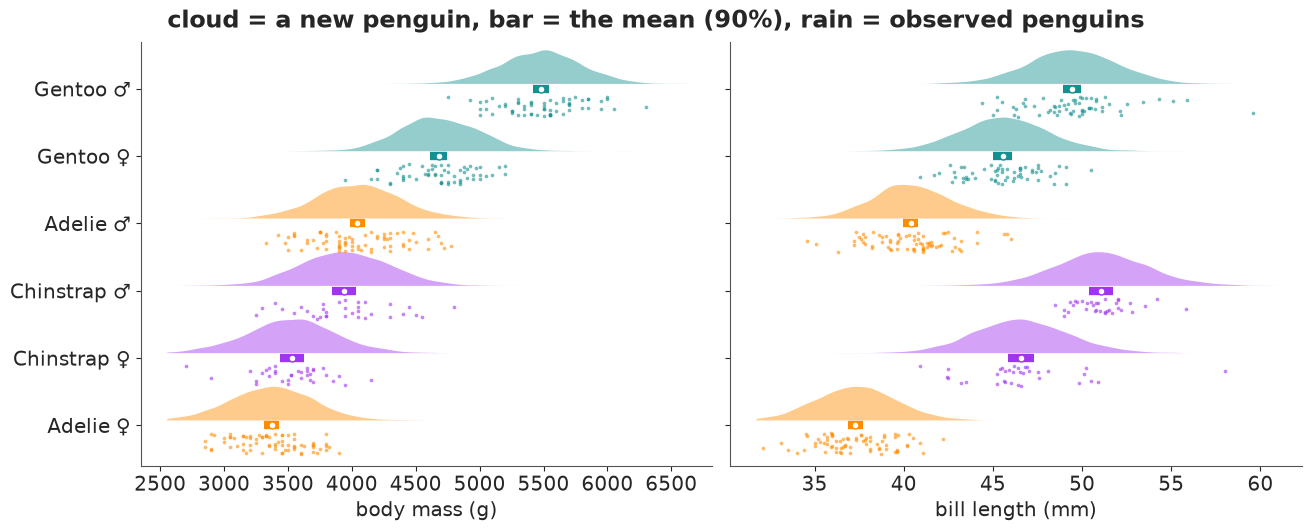

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), sharey=True)
for ax, m in zip(axes, ["body_mass", "bill_length"]):
    obs_m = y.sel(measurement=m)
    lo, hi = float(new.sel(measurement=m).quantile(0.001)), float(new.sel(measurement=m).max())
    g = xr.DataArray(np.linspace(lo, hi, 300), dims="value")
    for i, grp in enumerate(ORDER):
        sp, sx = grp.split()
        c = COLORS[sp]
        cloud = density(new.sel(species=sp, sex=sx, measurement=m), g)
        ax.fill_between(g, i + 0.08, i + 0.08 + 0.5 * cloud / cloud.max(), color=c, alpha=0.45,
                        lw=0)
        q = mu.sel(species=sp, sex=sx, measurement=m).quantile([0.05, 0.5, 0.95], dim="sample")
        ax.plot(q.values[[0, 2]], [i, i], color=c, lw=6, solid_capstyle="butt")
        ax.plot(q.values[1], i, "o", color="white", mec=c, ms=5)
        rain = obs_m.where((obs_m.species == sp) & (obs_m.sex == sx), drop=True)
        ax.scatter(rain, i - 0.12 - 0.3 * rng.random(rain.size), s=7, color=c, alpha=0.6, lw=0)
    ax.set(xlabel=f"{m.replace('_', ' ')} ({UNITS[m]})", ylim=(-0.6, 5.7))
axes[0].set_yticks(range(6), [LABEL[g] for g in ORDER])
fig.suptitle("cloud = a new penguin, bar = the mean (90%), rain = observed penguins");

The 90% bars for the means are 150-250 g wide; the middle 90% of a cloud, a single penguin,
spans about 1,000 g. An Adelie male and a Chinstrap male have almost the same predictive
cloud, and a Gentoo female overlaps the heavier Adelie and Chinstrap males. In bill length
the species separate much better (Adelie clouds mostly below 45 mm, Chinstrap above 42 mm),
though an Adelie male and a Chinstrap female can still be confused. The rain sits inside the
clouds, which is a quick visual posterior predictive check per group.

## 5 · Contrasts and rankings: renaming a dim to compare every pair

**Question: for every pair of groups, how sure are we that one is bigger?** The trick is to
make two copies of the same array that differ only in the *name* of the group dim.
`mug.rename(group="g1") - mug.rename(group="g2")` then broadcasts into all 6 x 6 pairs for
every measurement and draw - 36 contrasts x 4 measurements x 4000 draws in one line.
`(diff > 0).mean("sample")` is the posterior probability that the row group is larger.

('measurement', 'sample', 'g1', 'g2') -> ('measurement', 'g1', 'g2')


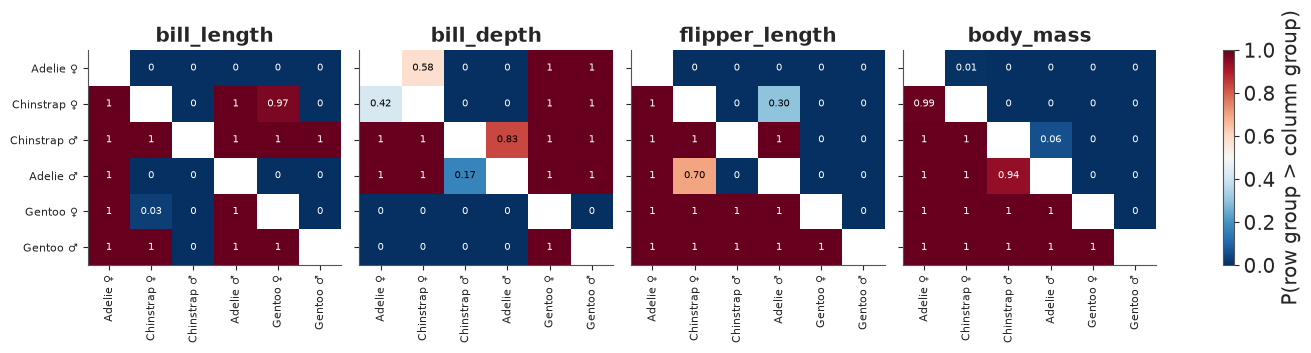

In [16]:
mug0 = mug.drop_vars(["species", "sex"])  # conflicting non-index coords would be dropped anyway
diff = mug0.rename(group="g1") - mug0.rename(group="g2")
p_bigger = (diff > 0).mean("sample").where(diff.g1 != diff.g2)
print(diff.dims, "->", p_bigger.dims)

fg = p_bigger.assign_coords(g1=np.arange(6), g2=np.arange(6)).plot(
    x="g2", y="g1", col="measurement", col_wrap=4, cmap="RdBu_r", vmin=0, vmax=1,
    yincrease=False, size=3.3, aspect=1.0, cbar_kwargs={"label": "P(row group > column group)"},
)
for ax, m in zip(fg.axs.flat, MEAS):
    for (i, j), v in np.ndenumerate(p_bigger.sel(measurement=m).values):
        if np.isfinite(v):
            txt = f"{v:.2f}" if 0.005 < v < 0.995 else ("1" if v > 0.5 else "0")
            ax.text(j, i, txt, ha="center", va="center", fontsize=7,
                    color="white" if abs(v - 0.5) > 0.4 else "black")
    ax.set_xticks(range(6), [LABEL[g] for g in ORDER], rotation=90, fontsize=8)
    ax.set_yticks(range(6), [LABEL[g] for g in ORDER], fontsize=8)
    ax.set(xlabel="", ylabel="")
fg.set_titles("{value}");

Almost every cell is saturated (0 or 1): with this much data, the ordering of
group means is settled for most pairs. The informative cells are the few in between, and the
matrix finds them without us having to guess which pairs to test: Adelie vs Chinstrap of the
same sex in bill depth (0.58 for females, 0.83 for males: a coin flip and a lean), Adelie
males vs Chinstrap females in flipper length (0.70), Adelie vs Chinstrap males in body mass
(0.94) and Chinstrap vs Gentoo females in bill length (0.97). Because each matrix is ordered
by body mass, the mass panel is a clean triangle, and the other panels show at a glance how
differently the other measurements order the same groups.

**Ranks: who is biggest, and how sure are we of the whole ordering?** Per draw and per
measurement we rank the six groups (1 = largest). xarray's `.rank` needs the optional
`bottleneck` package, which is not installed here, so we lift `scipy.stats.rankdata` with
`apply_ufunc` (the `group` dim is both the input and output core dim). Comparing the ranks
with a `rank` array broadcasts into a `(measurement, group, rank)` table of probabilities.

In [17]:
def rank_desc(da: xr.DataArray, dim: str) -> xr.DataArray:
    """Rank along `dim` in every other slice: 1 = largest."""
    return xr.apply_ufunc(rankdata, -da, input_core_dims=[[dim]], output_core_dims=[[dim]],
                          kwargs={"axis": -1})


ranks = rank_desc(mug0, "group")
rank_values = xr.DataArray(np.arange(1, 7), dims="rank", coords={"rank": np.arange(1, 7)})
p_rank = (ranks == rank_values).mean("sample")  # (measurement, group, rank)
print("P(the most probable rank), by group and measurement:")
p_rank.max("rank").to_pandas().T.round(2)

P(the most probable rank), by group and measurement:


measurement,bill_length,bill_depth,flipper_length,body_mass
group,,,,
Adelie female,1.00,0.58,1.0,0.99
Chinstrap female,0.97,0.58,0.7,0.99
Chinstrap male,1.00,0.83,1.0,0.94
Adelie male,1.00,0.83,0.7,0.94
Gentoo female,0.97,1.00,1.0,1.00
Gentoo male,1.00,1.00,1.0,1.00


A **bump chart** puts the four measurements on the x axis and rank on the y axis. Each line
is a group through its posterior mean rank; each circle's area is the probability of that
rank. Ties in the posterior show up as two half-size circles in one column.

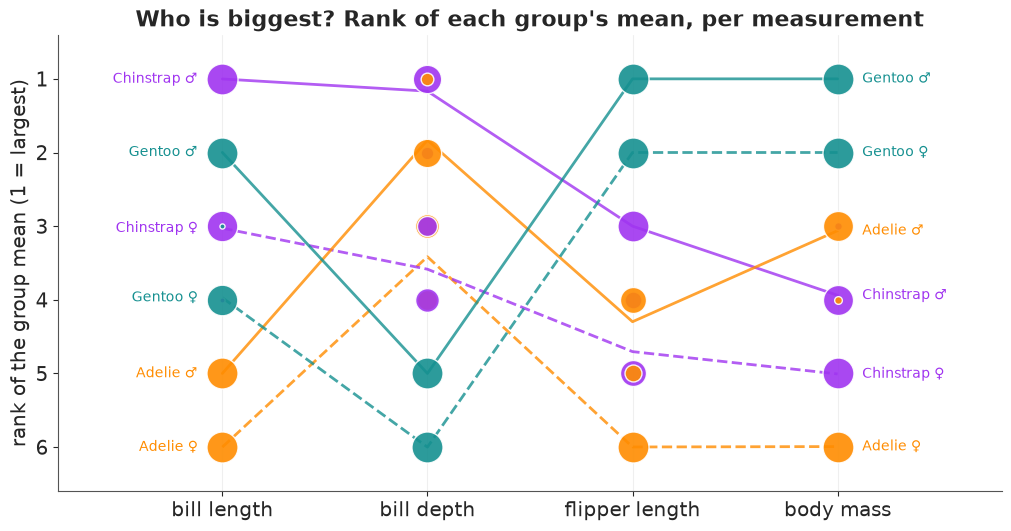

In [18]:
fig, ax = plt.subplots(figsize=(10, 5.2))
x = np.arange(4)
mean_rank = ranks.mean("sample")
for grp in ORDER:
    sp, sx = grp.split()
    c, ls = COLORS[sp], "-" if sx == "male" else "--"
    ax.plot(x, mean_rank.sel(group=grp).sel(measurement=MEAS), color=c, ls=ls, lw=2, alpha=0.8)
    pr = p_rank.sel(group=grp).sel(measurement=MEAS)
    for k in range(4):
        for r in range(1, 7):
            p = float(pr.isel(measurement=k).sel(rank=r))
            if p > 0.01:
                ax.scatter(k, r, s=500 * p, color=c, alpha=0.9, ec="white", lw=1, zorder=3)
    ax.text(-0.12, float(mean_rank.sel(group=grp, measurement=MEAS[0])), LABEL[grp], color=c,
            ha="right", va="center", fontsize=10)
    ax.text(3.12, float(mean_rank.sel(group=grp, measurement=MEAS[-1])), LABEL[grp], color=c,
            ha="left", va="center", fontsize=10)
ax.set_xticks(x, [m.replace("_", " ") for m in MEAS])
ax.set(xlim=(-0.8, 3.8), ylim=(6.6, 0.4), ylabel="rank of the group mean (1 = largest)",
       yticks=range(1, 7), title="Who is biggest? Rank of each group's mean, per measurement")
ax.grid(axis="x", alpha=0.3);

The chart shows why "biggest penguin" is not one question. Gentoo males lead on flipper
length and body mass, are 2nd in bill length and drop to 5th on bill depth, behind all four
Adelie and Chinstrap groups; Chinstrap males are the longest-billed and (probably) the
deepest-billed. The real doubts are where circles split: in bill depth Chinstrap and Adelie
males share ranks 1-2 (83:17) and their females ranks 3-4 (58:42), and in flipper length
Adelie males and Chinstrap females share ranks 4-5 (70:30). Everywhere else the ordering of
the means is settled. A ranking is a derived quantity like any other: compute it per draw, then
summarise.

## 6 · Parallel coordinates: the posterior is a joint distribution

**Question: which parameters drive the uncertainty in a derived quantity?** Every display so
far showed one quantity at a time. A draw, though, is a *vector*: its four means belong
together. In parallel coordinates each draw is one polyline across the four measurements
(each axis standardised over the draws so they share a scale). Colouring the lines by a
**derived quantity** threads it through every axis: where the colours sort on an axis, that
parameter drives the derived quantity; where they mix, it does not. Our derived quantity is
the **bill ratio**, mean length / mean depth, a shape index (long, narrow bills score high),
computed per draw by plain division of two `.sel`s. We use Chinstrap females, the smallest
group (34 penguins) and so the widest posterior.

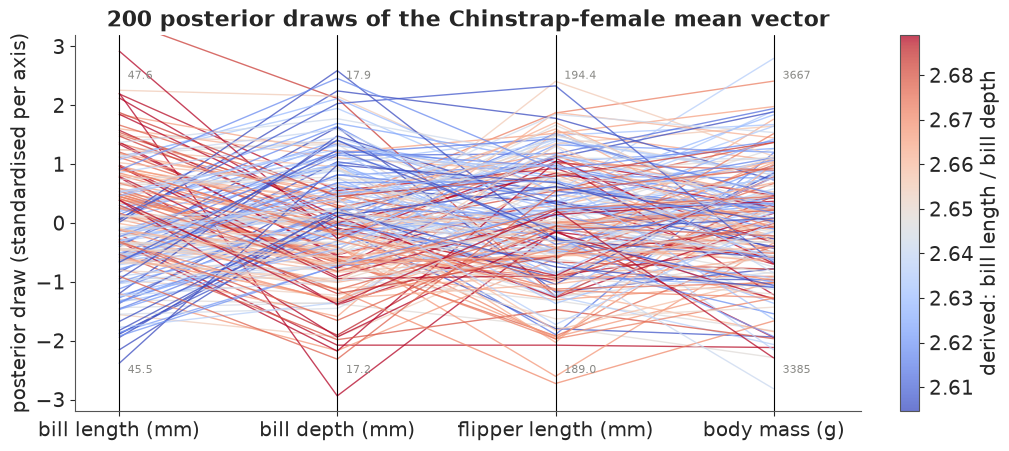

In [19]:
cf = mu.sel(species="Chinstrap", sex="female").isel(sample=slice(None, None, 20))  # 200 draws
cf_std = ((cf - cf.mean("sample")) / cf.std("sample")).transpose("sample", "measurement")
bill_ratio = cf.sel(measurement="bill_length") / cf.sel(measurement="bill_depth")

segments = np.stack([np.broadcast_to(np.arange(4), (cf.sizes["sample"], 4)), cf_std.values], -1)
fig, ax = plt.subplots(figsize=(10, 4.4))
lo_hi = bill_ratio.quantile([0.05, 0.95]).values  # clip the colour scale to the middle 90%
lc = LineCollection(segments, array=bill_ratio.values, cmap="coolwarm", lw=1, alpha=0.75,
                    norm=plt.Normalize(*lo_hi))
ax.add_collection(lc)
for k, m in enumerate(MEAS):
    ax.axvline(k, color="k", lw=0.8)
    for qv in [-2.5, 2.5]:
        val = float(cf.sel(measurement=m).mean() + qv * cf.sel(measurement=m).std())
        ax.text(k + 0.04, qv, f"{val:.1f}" if UNITS[m] == "mm" else f"{val:.0f}",
                ha="left", va="center", fontsize=8, color=GREY)
ax.set_xticks(range(4), [f"{m.replace('_', ' ')} ({UNITS[m]})" for m in MEAS])
ax.set(xlim=(-0.2, 3.4), ylim=(-3.2, 3.2), ylabel="posterior draw (standardised per axis)",
       title="200 posterior draws of the Chinstrap-female mean vector")
fig.colorbar(lc, ax=ax, label="derived: bill length / bill depth");

The colours sort on the first two axes, in *opposite* directions: red (high
ratio) lines are high on bill length and low on bill depth, blue ones the reverse, so they
cross in an X between the two axes. On flipper length and body mass the colours are mixed: the
ratio's uncertainty comes from the two bill means alone. The lines also cross a lot
everywhere, i.e. the means are only weakly correlated a posteriori. A small calculation says
what to expect: with $n$ penguins a mean's sampling covariance is $\Sigma / n$, so the
posterior correlation of the four means should look like the within-species correlation of
individuals. `xr.corr` over `sample` (between means, all 4000 draws) next to the model's
correlation matrix (between penguins) checks it:

In [20]:
cf_all = mu.sel(species="Chinstrap", sex="female")
corr_means = xr.corr(cf_all, cf_all.rename(measurement="measurement_b"), dim="sample")
corr_indiv = post["corr"].sel(species="Chinstrap").mean("sample")
compare = xr.concat([corr_means, corr_indiv],
                    dim=pd.Index(["between means (draws)", "between penguins (model)"],
                                 name="kind"))
compare.to_series().unstack("measurement_b").round(2)

measurement_b                            bill_length  bill_depth  \
kind                     measurement                               
between means (draws)    bill_length            1.00        0.26   
                         bill_depth             0.26        1.00   
                         flipper_length         0.12        0.26   
                         body_mass              0.22        0.32   
between penguins (model) bill_length            1.00        0.27   
                         bill_depth             0.27        1.00   
                         flipper_length         0.11        0.25   
                         body_mass              0.21        0.32   

measurement_b                            flipper_length  body_mass  
kind                     measurement                                
between means (draws)    bill_length               0.12       0.22  
                         bill_depth                0.26       0.32  
                         flipper_length            1.00       0.42  
                         body_mass                 0.42       1.00  
between penguins (model) bill_length               0.11       0.21  
                         bill_depth                0.25       0.32  
                         flipper_length            1.00       0.44  
                         body_mass                 0.44       1.00

The two matrices agree to within 0.02, as the $\Sigma / n$ argument predicts. Why this matters: a
derived quantity that combines several means (a bill ratio, a "size index", a difference of
two measurements) must be computed **per draw**, as we did; combining the marginal intervals
of its ingredients would ignore exactly the dependence this plot shows.

## 7 · Posterior predictive ellipses, contours and an animation

**Question: what do new penguins of each group look like in two dimensions, and how sure is
the model about that shape?** For a bivariate normal the $p$ contour is the unit circle
stretched by the Cholesky factor: $\boldsymbol\mu + r_p L \,(\cos\theta, \sin\theta)$ with
$r_p^2$ the $\chi^2_2$ quantile. In xarray that is the unit circle as an array with dims
`(measurement_b, angle)`, the radii as an array with dim `level`, and one `xr.dot` - an
ellipse for every level, group and posterior draw at once, with no loop and no eigenvalues.

In [21]:
pair = ["bill_length", "bill_depth"]
thin = slice(None, None, 10)  # 400 draws are plenty for spaghetti and animation
angle = xr.DataArray(np.linspace(0, 2 * np.pi, 61), dims="angle")
unit_circle = xr.concat([np.cos(angle), np.sin(angle)],
                        dim=pd.Index(pair, name="measurement_b"))
radius = xr.DataArray(np.sqrt(chi2.ppf([0.5, 0.9], df=2)), dims="level",
                      coords={"level": [0.5, 0.9]})
L_pair = chol_factor(cov.isel(sample=thin).sel(measurement=pair, measurement_b=pair))
ellipse = mu.isel(sample=thin).sel(measurement=pair) + radius * xr.dot(
    L_pair, unit_circle, dim="measurement_b"
)
print(ellipse.dims, dict(ellipse.sizes))

('species', 'sex', 'measurement', 'sample', 'level', 'angle') {'species': 3, 'sex': 2, 'measurement': 2, 'sample': 400, 'level': 2, 'angle': 61}


Left: 40 posterior draws of the 90% predictive ellipse per group over the
observed penguins (circles female, triangles male), and the pooled least-squares line that
ignores species. Right: the tidy route for a 2-D density - the predictive draws of new
penguins go to seaborn's `kdeplot` for contours enclosing 50% and 90% of new penguins, per
species.

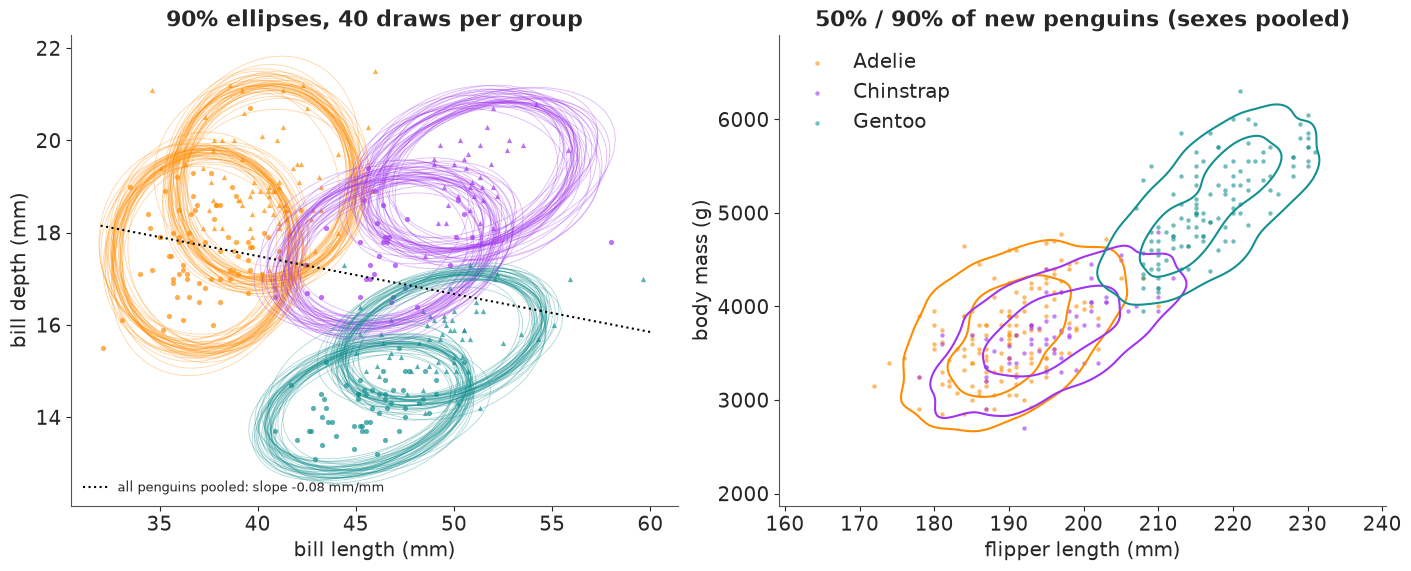

In [22]:
obs_df = y.to_dataset(dim="measurement").to_dataframe()  # one column per measurement
fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))
ax = axes[0]
for sp in SPECIES:
    o = obs_df[obs_df.species == sp]
    for sx, mk in [("female", "o"), ("male", "^")]:
        oo = o[o.sex == sx]
        ax.scatter(oo.bill_length, oo.bill_depth, s=14, marker=mk, color=COLORS[sp], alpha=0.7,
                   lw=0)
    for sx in SEXES:
        e = ellipse.sel(species=sp, sex=sx, level=0.9).isel(sample=slice(0, 40))
        ax.plot(e.sel(measurement="bill_length").T, e.sel(measurement="bill_depth").T,
                color=COLORS[sp], lw=0.6, alpha=0.35)
slope, icpt = np.polyfit(obs_df.bill_length, obs_df.bill_depth, 1)
xx = np.array([32, 60])
ax.plot(xx, icpt + slope * xx, color="k", lw=1.5, ls=":",
        label=f"all penguins pooled: slope {slope:+.2f} mm/mm")
ax.set(xlabel="bill length (mm)", ylabel="bill depth (mm)",
       title="90% ellipses, 40 draws per group")
ax.legend(loc="lower left", fontsize=9)

ax = axes[1]
new_df = (new.isel(sample=slice(None, None, 4)).sel(measurement=["flipper_length", "body_mass"])
          .to_dataset(dim="measurement").to_dataframe().reset_index())
for sp in SPECIES:
    sns.kdeplot(new_df[new_df.species == sp], x="flipper_length", y="body_mass",
                levels=[0.1, 0.5], color=COLORS[sp], linewidths=1.5, ax=ax)
    o = obs_df[obs_df.species == sp]
    ax.scatter(o.flipper_length, o.body_mass, s=10, color=COLORS[sp], alpha=0.6, lw=0,
               label=sp)
ax.set(xlabel="flipper length (mm)", ylabel="body mass (g)",
       title="50% / 90% of new penguins (sexes pooled)")
ax.legend(loc="upper left");

On the left, the pooled line slopes *down* (longer bills are shallower) while
every group's ellipse tilts *up* - Simpson's paradox again, now in data space. The spaghetti
shows how well each ellipse's size and tilt is known: tight bundles for the Adelie and Gentoo
groups, a little looser for the smaller Chinstrap groups (34 birds each). On the right,
Gentoos form their own island of long flippers and high mass, while the Adelie and Chinstrap
contours sit almost on top of each other: in these two measurements the two species are the
same kind of penguin.

### Hypothetical outcome plot: one posterior draw per frame

Instead of drawing 40 ellipses at once, show them one at a time (Hullman et al. 2015; see
E16). Each frame is one posterior draw: its six 90% ellipses and one **replicated colony**,
i.e. a posterior predictive copy of all 333 penguins. The replicate comes from vectorised
selection: `mu.sel(species=y.species, sex=y.sex)` looks up each observed penguin's group and
returns an array along `penguin` - the named version of `mu[sp_idx, sx_idx]`; the matching
Cholesky factor comes the same way, and `xr.dot` makes the correlated noise.

In [23]:
n_frames = 40
sub = slice(0, n_frames * 10, 10)  # the same draws as the first 40 thinned ellipses
eps_obs = xr.DataArray(rng.standard_normal((n_frames, y.sizes["penguin"], 4)),
                       dims=("sample", "penguin", "measurement_b"))
colony = mu.isel(sample=sub).sel(species=y.species, sex=y.sex) + xr.dot(
    L.isel(sample=sub).sel(species=y.species), eps_obs, dim="measurement_b"
)
print(colony.dims)

fig, ax = plt.subplots(figsize=(6.4, 4.4), dpi=72)
ax.scatter(y.sel(measurement="bill_length"), y.sel(measurement="bill_depth"), s=10,
           color=GREY, alpha=0.25, lw=0, label="observed")
species_of = y.species.values
dots = ax.scatter(colony.isel(sample=0).sel(measurement="bill_length"),
                  colony.isel(sample=0).sel(measurement="bill_depth"), s=12,
                  c=[COLORS[s] for s in species_of], alpha=0.8, lw=0)
lines = {}
for sp in SPECIES:
    for sx in SEXES:
        e = ellipse.sel(species=sp, sex=sx, level=0.9).isel(sample=0)
        (lines[sp, sx],) = ax.plot(e.sel(measurement="bill_length"),
                                   e.sel(measurement="bill_depth"), color=COLORS[sp], lw=1.8)
title = ax.set_title("posterior draw 1/40", fontsize=11)
ax.set(xlabel="bill length (mm)", ylabel="bill depth (mm)", xlim=(30, 62), ylim=(12, 23))
plt.close(fig)  # show only the animation


def update(i):
    c = colony.isel(sample=i)
    dots.set_offsets(np.c_[c.sel(measurement="bill_length"), c.sel(measurement="bill_depth")])
    for (sp, sx), line in lines.items():
        e = ellipse.sel(species=sp, sex=sx, level=0.9).isel(sample=i)
        line.set_data(e.sel(measurement="bill_length"), e.sel(measurement="bill_depth"))
    title.set_text(f"posterior draw {i + 1}/40: ellipses + a replicated colony")
    return dots, title


hops = animation.FuncAnimation(fig, update, frames=n_frames, interval=400, blit=False)
HTML(hops.to_jshtml(default_mode="loop"))

('penguin', 'measurement', 'sample')


Played at 400 ms per frame, the ellipses shift only a little (most for the
Chinstrap groups) while the replicated colony reshuffles completely each time: most of the
variation you *see* is penguins, not parameters. A static band makes that distinction only to
readers who already know it.

## 8 · Quantile dotplots: twenty penguins you can count

**Question: I will weigh the next penguin I catch. How likely is it to be over 4 kg?**
`.quantile(levels, dim="sample")` with 20 equally spaced levels turns each group's predictive
distribution into 20 equally likely penguins, returned with a `quantile` dim. Stacked into a
dotplot (Kay et al. 2016), "the probability" becomes "count the dots right of the line":
each dot is one penguin in twenty, 5%.

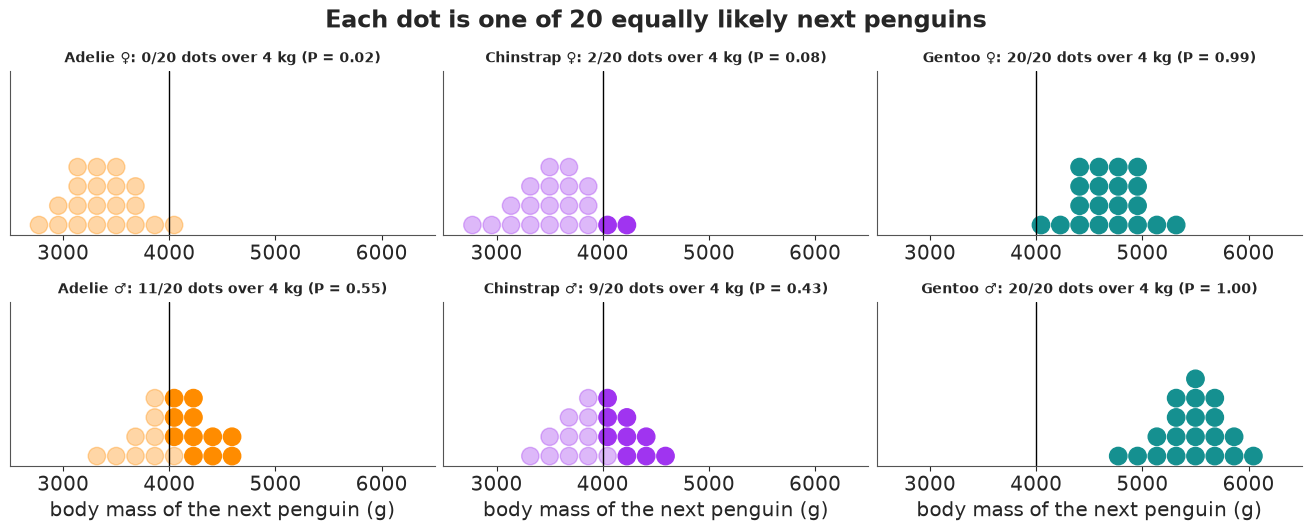

In [24]:
def quantile_dotplot(ax, q, n_bins=22, xlim=(2500, 6500), color="k", threshold=None):
    """Wilkinson-style dotplot of quantiles `q` (1-D), stacked in n_bins columns."""
    edges = np.linspace(*xlim, n_bins + 1)
    width = edges[1] - edges[0]
    cols = np.clip(np.digitize(q, edges) - 1, 0, n_bins - 1)
    heights = np.zeros(n_bins, int)
    for v, cidx in zip(q, cols):
        hit = threshold is not None and v > threshold
        ax.add_patch(Ellipse((edges[cidx] + width / 2, heights[cidx] + 0.5), width * 0.9, 0.9,
                             color=color, alpha=1.0 if hit else 0.35))
        heights[cidx] += 1
    ax.set(xlim=xlim, ylim=(0, 8.5), yticks=[])
    ax.set_aspect(width)


levels = (np.arange(20) + 0.5) / 20
mass_q = new.sel(measurement="body_mass").quantile(levels, dim="sample")
p_over = (new.sel(measurement="body_mass") > 4000).mean("sample")

fig, axes = plt.subplots(2, 3, figsize=(13, 5.2))
for ax, (sx, sp) in zip(axes.flat, [(x_, s_) for x_ in SEXES for s_ in SPECIES]):
    q = mass_q.sel(species=sp, sex=sx).values
    quantile_dotplot(ax, q, color=COLORS[sp], threshold=4000)
    ax.axvline(4000, color="k", lw=1)
    ax.set_title(f"{sp} {SYMBOL[sx]}: {(q > 4000).sum()}/20 dots over 4 kg "
                 f"(P = {float(p_over.sel(species=sp, sex=sx)):.2f})", fontsize=10)
    ax.set_xlabel("body mass of the next penguin (g)" if sx == "male" else "")
fig.suptitle("Each dot is one of 20 equally likely next penguins");

Count, do not estimate: roughly half of the next Adelie males and a bit fewer Chinstrap males
will weigh over 4 kg, almost every Gentoo will, and very few Adelie or Chinstrap females. The
dot counts match the exact probabilities in the titles to within one dot (5%), which is all
the precision a reader can use.

## 9 · The tidy hand-off: `to_dataframe()` and seaborn

Some displays are simply what seaborn is built for - here a posterior predictive check as
**ECDFs** of 30 replicated datasets against the data, faceted by species and measurement.
To get there we make the replicates in xarray (vectorised `.sel` again, for 30 draws) and
`xr.concat` them with the observed data along a new named dim `source`; `to_dataframe()`
then gives exactly the long table seaborn wants, with `species` and `sex` as ordinary
columns because they were coordinates.

In [25]:
n_rep = 30
reps = slice(0, n_rep * 100, 100)  # spread over the 4 chains
eps_rep = xr.DataArray(rng.standard_normal((n_rep, y.sizes["penguin"], 4)),
                       dims=("sample", "penguin", "measurement_b"))
yrep = mu.isel(sample=reps).sel(species=y.species, sex=y.sex) + xr.dot(
    L.isel(sample=reps).sel(species=y.species), eps_rep, dim="measurement_b"
)
yrep = yrep.drop_vars(["sample", "chain", "draw"]).assign_coords(sample=np.arange(n_rep))
both = xr.concat(
    [y.expand_dims(sample=[-1]), yrep], dim="sample"
).rename("value")
tidy = both.to_dataframe().reset_index()
tidy["source"] = np.where(tidy["sample"] < 0, "observed", "replicated")
tidy.head()

,sample,measurement,penguin,species,island,sex,value,source
0,-1,bill_length,1,Adelie,Torgersen,male,39.1,observed
1,-1,bill_length,2,Adelie,Torgersen,female,39.5,observed
2,-1,bill_length,3,Adelie,Torgersen,female,40.3,observed
3,-1,bill_length,5,Adelie,Torgersen,female,36.7,observed
4,-1,bill_length,6,Adelie,Torgersen,male,39.3,observed


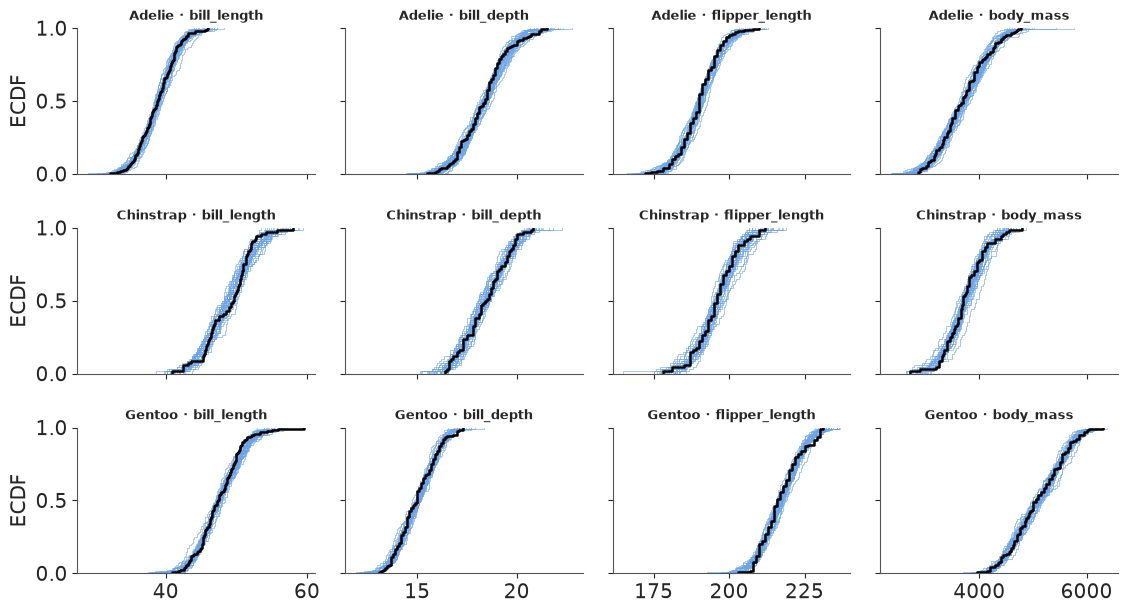

In [26]:
replicated = tidy[tidy.source == "replicated"]
g = sns.displot(
    replicated, x="value", kind="ecdf", hue="sample", row="species", col="measurement",
    row_order=SPECIES, col_order=MEAS,
    palette=["#6ba4e8"] * n_rep, legend=False, height=2.2, aspect=1.3,
    facet_kws={"sharex": "col"}, lw=0.7, alpha=0.6,
)
for (sp, m), ax in g.axes_dict.items():  # the observed ECDF on top, in black
    sel = tidy[(tidy.source == "observed") & (tidy.species == sp) & (tidy.measurement == m)]
    sns.ecdfplot(sel, x="value", ax=ax, color="k", lw=1.8)
g.set_titles("{row_name} · {col_name}", size=9)
g.set_axis_labels("", "ECDF");

In every one of the 12 panels the black observed ECDF runs inside (or along the
edge of) the blue band of 30 replicates: at the level of each species' marginal distributions,
the multivariate normal with sex-specific means reproduces the data. (A mixture of two sexes
with one mean would show up here as a too-smooth replicate band around a two-humped observed
curve.)

## 10 · Interactive: every group x measurement cell with the numbers on hover

The 24 group means fit in a 6 x 4 heatmap. Colour shows the posterior mean in population sds
(so all columns share a scale); hovering shows the numbers a reader would want to quote - the
mean and 90% interval in physical units and the probability that males are larger - all
computed by name beforehand and handed to plotly as arrays with matching `(group,
measurement)` order.

In [27]:
mu_z = by_group(post["mu"]).sel(group=ORDER, measurement=MEAS)
q_units = mug.sel(measurement=MEAS).quantile([0.05, 0.5, 0.95], dim="sample")
p_male = (mu.sel(sex="male") - mu.sel(sex="female") > 0).mean("sample")
p_male_g = p_male.sel(species=mug.species).sel(measurement=MEAS)  # vectorised: per group

hover = np.empty((6, 4), dtype=object)
for i, grp in enumerate(ORDER):
    for k, m in enumerate(MEAS):
        lo, med, hi = q_units.sel(group=grp, measurement=m).values
        hover[i, k] = (f"<b>{grp}</b>, {m.replace('_', ' ')}<br>mean {med:.1f} {UNITS[m]} "
                       f"(90%: {lo:.1f}-{hi:.1f})<br>P(males larger in "
                       f"{grp.split()[0]}) = {float(p_male_g.sel(group=grp, measurement=m)):.3f}")

fig = go.Figure(go.Heatmap(
    # .values is where names end: transpose BY NAME first, or plotly gets a 4 x 6 grid
    z=mu_z.mean("sample").transpose("group", "measurement").values,
    x=[m.replace("_", " ") for m in MEAS], y=ORDER,
    colorscale="RdBu_r", zmid=0, text=hover, hovertemplate="%{text}<extra></extra>",
    colorbar=dict(title="population sds"),
))
fig.update_layout(template="plotly_white", width=720, height=420,
                  title="Posterior mean of each group, in population sds (hover for numbers)")
fig

Section 3 on one screen: the two Gentoo rows are red or pink (large) everywhere except bill
depth, the Adelie female row is blue except bill depth, and Chinstrap males are the reddest
cell in bill length. One trap on the way from xarray to any plotting library: `.values` drops the
names, so the dimension order must be fixed **by name** (`.transpose("group",
"measurement")`) right before it. Without that line this cell ran silently and drew a wrong
heatmap with the axes swapped and two rows empty.

## 11 · A posterior over a missing label: sexing the unsexed penguins

Nine penguins were measured but their sex was not recorded. The model says what males and
females of each species look like, so for each of them and each posterior draw we can
compute the probability of being male from Bayes' rule (with even prior odds):

$$
\log\frac{P(\text{male}\mid \mathbf z)}{P(\text{female}\mid \mathbf z)} =
-\tfrac12 \left(d^2_{\text{male}} - d^2_{\text{female}}\right),
\qquad d^2_x = (\mathbf z - \boldsymbol\mu_{s,x})^\top \Sigma_s^{-1} (\mathbf z -
\boldsymbol\mu_{s,x})
$$

(the determinants cancel because both sexes share the species covariance). The xarray
version reads like the formula: vectorised `.sel(species=...)` picks each bird's species
parameters, the residual keeps a `sex` dim, and `np.linalg.solve` lifted by `apply_ufunc`
with matrix and vector core dims gives $\Sigma^{-1}\mathbf r$ for every bird, sex and draw.

In [28]:
zu = (unsexed - center) / scale  # (measurement, penguin)
resid = zu - post["mu"].sel(species=zu.species)  # (sex, measurement, sample, penguin)
cov_z = (post["corr"] * post["sigma"] * post["sigma"].rename(measurement="measurement_b")).sel(
    species=zu.species
)
solved = xr.apply_ufunc(
    lambda a, b: np.linalg.solve(a, b[..., None])[..., 0],
    cov_z, resid.rename(measurement="measurement_b"),
    input_core_dims=[["measurement", "measurement_b"], ["measurement_b"]],
    output_core_dims=[["measurement"]],
)
d2 = xr.dot(resid, solved, dim="measurement")
p_male_bird = expit(-0.5 * (d2.sel(sex="male") - d2.sel(sex="female")))
summary = p_male_bird.quantile([0.05, 0.5, 0.95], dim="sample").T
summary = summary.sortby(p_male_bird.mean("sample"))
table = summary.to_pandas().round(3)
table.insert(0, "species", summary.species.values)
table

quantile,species,0.05,0.5,0.95
penguin,,,,
179,Gentoo,0.000,0.000,0.002
257,Gentoo,0.001,0.005,0.023
219,Gentoo,0.003,0.009,0.028
11,Adelie,0.006,0.018,0.045
48,Adelie,0.004,0.017,0.064
9,Adelie,0.005,0.019,0.059
12,Adelie,0.079,0.184,0.371
269,Gentoo,0.173,0.444,0.739
10,Adelie,0.994,0.998,1.000


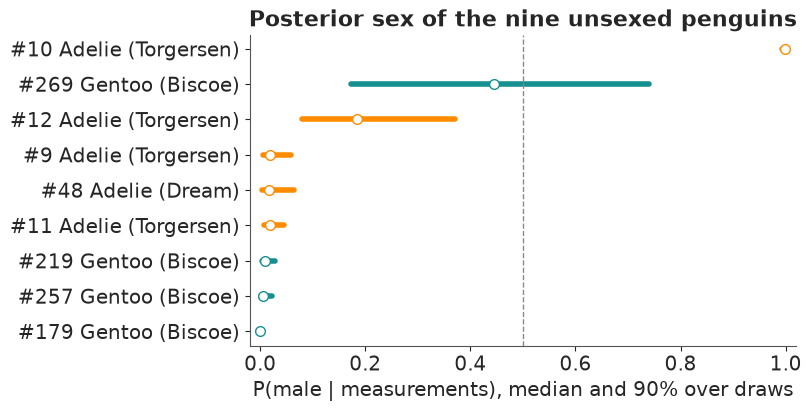

In [29]:
fig, ax = plt.subplots(figsize=(8, 4))
for i, pid in enumerate(summary.penguin.values):
    s = summary.sel(penguin=pid)
    c = COLORS[str(s.species.values)]
    ax.plot([s.sel(quantile=0.05), s.sel(quantile=0.95)], [i, i], color=c, lw=4)
    ax.plot(s.sel(quantile=0.5), i, "o", color="white", mec=c, ms=7)
ax.set_yticks(range(summary.sizes["penguin"]),
              [f"#{p} {s} ({isl})" for p, s, isl in zip(summary.penguin.values,
                                                         summary.species.values,
                                                         summary.island.values)])
ax.axvline(0.5, color=GREY, ls="--", lw=1)
ax.set(xlim=(-0.02, 1.02), xlabel="P(male | measurements), median and 90% over draws",
       title="Posterior sex of the nine unsexed penguins");

Seven of the nine are called with near certainty: six females (P(male) below 0.07 across
the draws) and one male, #10. Penguin #12 is probably female (median 0.18, 90% 0.08-0.37),
and #269 is a genuine toss-up whose bar runs from 0.17 to 0.74: the model cannot even say
*how* uncertain it is, because that bird sits between the Gentoo ellipses and small changes
in the parameters move it from one side to the other. The width of each bar is the parameter
uncertainty; its position is the bird. This is the honest way to
fill in a missing label: impute a probability (or better, keep the bird in the model with sex
as a latent variable) rather than a hard guess.

## 12 · The idioms on one page

| Display / question | The xarray move |
|---|---|
| table -> labelled array | `df.to_xarray().set_coords([...])`, `ds[vars].to_dataarray("measurement")` |
| back to physical units | `z * scale + center` (broadcast on `measurement`) |
| covariance from sds and correlations | `corr * sd * sd.rename(measurement="measurement_b")` |
| per-slice linear algebra | `xr.apply_ufunc(np.linalg.cholesky / solve, ..., input_core_dims=...)` |
| correlated draws, ellipses | `xr.dot(L, eps, dim="measurement_b")`, a unit circle with an `angle` dim |
| densities for any grid of groups | `xr.apply_ufunc(kde, da, grid, ..., vectorize=True)` |
| FacetGrid in one call | `.plot.line(x=..., hue=..., col=..., row=...)`, `.plot(col=..., col_wrap=...)` |
| one categorical axis, ordered | `stack(group=("species", "sex"))`, `sortby(...)` |
| all pairwise contrasts | `a.rename(group="g1") - a.rename(group="g2")` |
| ranks per draw | `apply_ufunc(scipy.stats.rankdata, ...)` (`.rank` needs bottleneck) |
| P(rank = k) | `(ranks == xr.DataArray(range(1, 7), dims="rank")).mean("sample")` |
| per-observation parameters | vectorised `mu.sel(species=y.species, sex=y.sex)` |
| correlation between labelled variables | `xr.corr(a, a.rename(...), dim=...)` |
| side-by-side comparison | `xr.concat([...], dim=pd.Index([...], name="kind"))` |
| tidy tools | `.to_dataset(dim="measurement").to_dataframe()` -> seaborn |

## Try it yourself

1. **Island within species.** Adelie penguins live on all three islands. Give Adelie means
   an `island` dim (the others have one island each), and redo the P(row > column) matrix for
   the five species-island groups. Do Adelies differ between islands?
2. **Rank the individuals, not the means.** Redo the bump chart with the *new-penguin* draws
   `new` instead of `mu`. How much less certain is "a random Gentoo female is heavier than a
   random Adelie male" than the same statement about means?
3. **A size-free shape.** Compute the bill ratio (length / depth) per draw, for means and for
   new penguins, and make a raincloud of it by group. Which species is easiest to identify
   from bill *shape* alone, and does the answer change between means and individuals?